## 📊 Customer Churn Prediction using Logistic Regression

# 🎯 Objective

The goal of this notebook is to build and evaluate a machine learning model 
to predict customer churn. 

We apply Logistic Regression and assess model performance using:
- Train–Test Split
- Cross-Validation
- Evaluation Metrics (Accuracy, Precision, Recall, F1-score)
- ROC Curve & AUC Score


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


# 📂 Dataset Overview

The dataset contains customer information from a telecom company.

Key attributes include:
- Demographics (Gender, SeniorCitizen, Partner, Dependents)
- Services (InternetService, PhoneService, StreamingTV, etc.)
- Account Info (Contract, Tenure, PaymentMethod)
- Charges (MonthlyCharges, TotalCharges)
- Target Variable: **Churn**


In [2]:
df = pd.read_csv('K:/Data Science Internship/WEEK 5/datasets/Telco-Customer-Churn-dataset-cleaned.csv')

In [3]:
X = df.drop("Churn", axis=1)   # features
y = df["Churn"]                # target
X = pd.get_dummies(X, drop_first=True)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## ✂ Train–Test Split

We split the dataset into training and testing sets to evaluate 
model generalization on unseen data.

- Training Set → Model learning
- Testing Set → Performance evaluation


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps class balance
)


# 🤖 Model Training – Logistic Regression

We use Logistic Regression as a baseline classifier.

Why Logistic Regression?
- Suitable for binary classification
- Interpretable
- Efficient on structured/tabular data


In [6]:
model = LogisticRegression()


In [7]:
model = LogisticRegression(max_iter=10000,
    class_weight='balanced')


In [8]:
model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=10000)

In [9]:
y_pred = model.predict(X_test)


# 📊 Model Evaluation Metrics

We evaluate performance using:

- **Accuracy** → Overall correctness
- **Precision** → Reliability of churn predictions
- **Recall** → Ability to detect churners
- **F1-score** → Balance of Precision & Recall


In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)


Accuracy : 0.7366926898509581
Precision: 0.5025553662691652
Recall   : 0.7887700534759359
F1-score : 0.6139438085327783


In [11]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.90      0.72      0.80      1035
         1.0       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



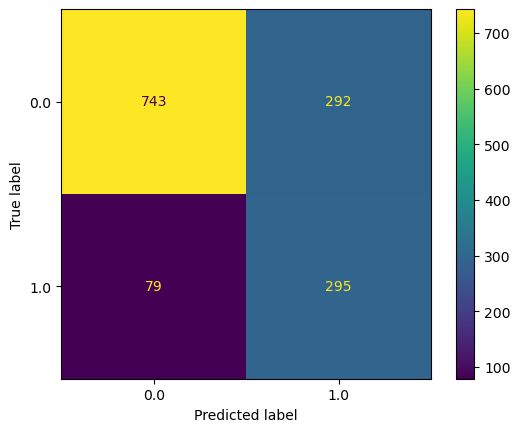

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


# 🔁 Cross-Validation

Cross-validation ensures model robustness by training and testing 
across multiple data splits.

We apply:
- K-Fold Cross Validation
- Stratified K-Fold (preserves class distribution)


In [13]:
from sklearn.model_selection import cross_val_score


In [14]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,              # 5-fold CV
    scoring='accuracy'
)

print("CV Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


CV Accuracy Scores: [0.75017743 0.7523066  0.73669269 0.74289773 0.75      ]
Mean CV Accuracy: 0.7464148896703013


In [15]:
cv_recall = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='recall'
)

print("Mean CV Recall:", cv_recall.mean())


Mean CV Recall: 0.799346245931958


In [16]:
cv_f1 = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='f1'
)

print("Mean CV F1:", cv_f1.mean())


Mean CV F1: 0.6257640388301643


In [17]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=skf, scoring='recall')
print("Stratified CV Recall:", cv_scores.mean())


Stratified CV Recall: 0.80468953850124


#  AUC Score
**AUC Score Interpretation:**
- Measures model’s discrimination ability
- AUC ≈ 0.84 → Very Good performance

# 📈 ROC Curve
The ROC Curve illustrates the trade-off between:
- True Positive Rate (Recall)
- False Positive Rate




In [18]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)


AUC Score: 0.8431966726084373


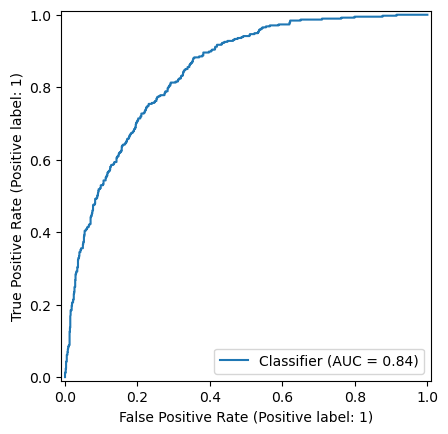

In [19]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob)


# 🏆 Final Observations

- Logistic Regression provides strong baseline performance
- Recall ≈ 80% → Excellent churn detection
- AUC ≈ 0.84 → Very Good discrimination
- Trade-off observed between Precision & Recall
